In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from aqua.diagnostics.ocean_stratification import PlotMLD, PlotStratification
from aqua.diagnostics.ocean_stratification.stratification import Stratification

%matplotlib inline

# Stratification Plot

In [3]:
strat = Stratification(
    catalog="climatedt-gen2",
    model="IFS-NEMO-5km",
    exp="baseline-hist",
    source="lra-r100-monthly",
    startdate="01-01-1991",
    enddate="31-12-1992",
    loglevel="INFO",
)

In [4]:
strat.run(
    dim_mean=["lat", "lon"],
    outputdir=".",
    var=["thetao", "so"],
    region="ls",
    mld=False,
    climatology="January",
)

2026-07-29 22:52:14 :: Stratification :: INFO     -> Starting stratification diagnostic run.
/home/b/b383197/miniforge3/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/home/b/b383197/miniforge3/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
2026-07-29 22:52:14 :: ConfigPath :: INFO     -> IFS-NEMO-5km_baseline-hist_lra-r100-monthly triplet found in in climatedt-gen2!
2026-07-29 22:52:14 :: Reader :: WARNING  -> The machine configured (levante) is different from the machine in the catalog (mn5). Please check that the data you are looking for are on the machine you are working on.
2026-07-29 22:52:15 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-07-29 22

2026-07-29 22:52:41 :: PlotStratification :: DEBUG    -> Variables in data: ['thetao', 'so', 'rho']
2026-07-29 22:52:41 :: OutputSaver :: DEBUG    -> Updating the log_level to DEBUG
2026-07-29 22:52:41 :: OutputSaver :: DEBUG    -> Complete initialization with parameters: {'diagnostic': 'ocean_stratification', 'catalog': 'climatedt-gen2', 'model': 'IFS-NEMO-5km', 'exp': 'baseline-hist', 'realization': 'r1', 'catalog_ref': None, 'model_ref': None, 'exp_ref': None}
2026-07-29 22:52:41 :: PlotStratification :: DEBUG    -> Suptitle set to: Stratification [Labrador Sea] for IFS-NEMO-5km baseline-hist January climatology
2026-07-29 22:52:41 :: PlotStratification :: DEBUG    -> Title list set to: ['Time-mean sea water potential temperature', 'Time-mean sea water practical salinity', 'Potential Density']
2026-07-29 22:52:41 :: PlotStratification :: DEBUG    -> X-axis text labels set to: ['thetao (K)', 'so (g kg$^{-1}$)', 'rho (kg m$^{-3}$)']
2026-07-29 22:52:41 :: ConfigPath :: DEBUG    -> Upd

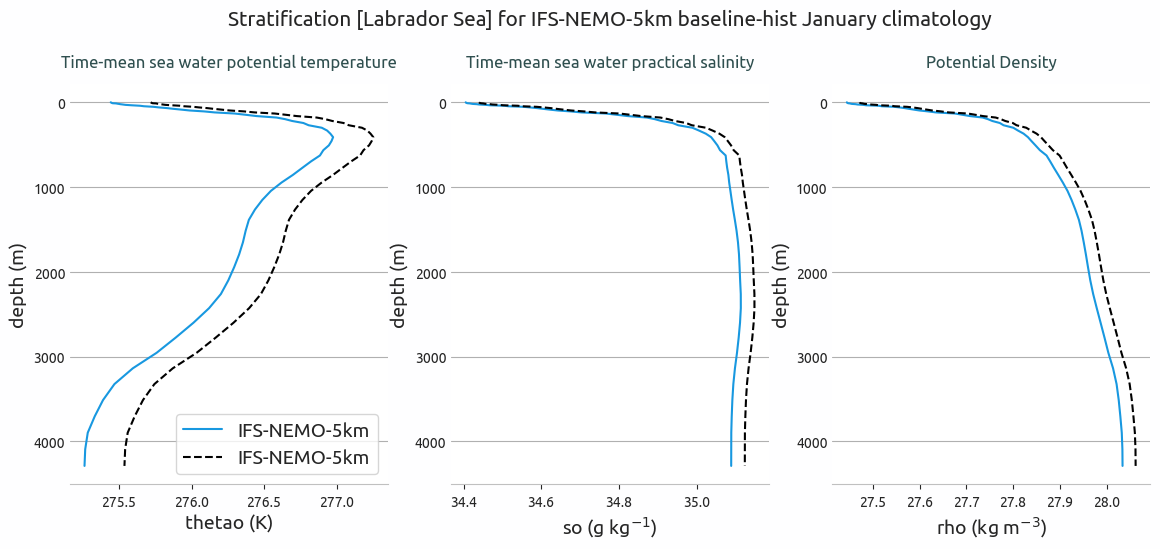

In [5]:
ps = PlotStratification(
    data=strat.data[["thetao", "so", "rho"]],
    obs=strat.data[["thetao", "so", "rho"]] * 1.001,  # just to have different data for obs
    loglevel="DEBUG",
)
ps.plot_stratification()

# Mixed layer depth Plot

In [6]:
mld_init = Stratification(
    catalog="climatedt-gen2",
    model="IFS-NEMO-5km",
    exp="baseline-hist",
    source="lra-r100-monthly",
    startdate="01-01-1991",
    enddate="31-12-1992",
    loglevel="DEBUG",
)

2026-07-29 22:52:43 :: Diagnostic :: DEBUG    -> Updating the log_level to DEBUG
2026-07-29 22:52:43 :: Stratification :: DEBUG    -> Updating the log_level to DEBUG


In [7]:
mld_init.run(
    # dim_mean=["lat","lon"],
    outputdir=".",
    var=["thetao", "so"],
    region="ls",
    mld=True,
    climatology="January",
)

2026-07-29 22:52:43 :: Stratification :: INFO     -> Starting stratification diagnostic run.
2026-07-29 22:52:43 :: Reader :: DEBUG    -> Updating the log_level to DEBUG
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> AQUA installation found in /home/b/b383197/.aqua
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Configuration file found in /home/b/b383197/.aqua/config-aqua.yaml
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Available catalogs are ['climatedt-gen2']
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Default catalog will be climatedt-gen2
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Catalog file is /home/b/b383197/.aqua/catalogs/climatedt-gen2/catalog.yaml
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Machine file is /home/b/b383197/.aqua/catalogs/climatedt-gen2/machine.yaml
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Machine found in configuration file, set to unknown
2026-07-29 22:52:43 :: ConfigPath :: DEBUG    -> Machine found in configuration file, se

2026-07-29 22:52:58 :: PlotStratification :: DEBUG    -> Variables in data: ['mld']
2026-07-29 22:52:58 :: OutputSaver :: DEBUG    -> Complete initialization with parameters: {'diagnostic': 'ocean_stratification', 'catalog': 'climatedt-gen2', 'model': 'IFS-NEMO-5km', 'exp': 'baseline-hist', 'realization': 'r1', 'catalog_ref': None, 'model_ref': None, 'exp_ref': None}
2026-07-29 22:52:58 :: PlotStratification :: DEBUG    -> Projection set to: PlateCarree
2026-07-29 22:52:58 :: PlotStratification :: DEBUG    -> Map extent set to: [array(300.), array(316.), array(52.5), array(64.5)]
2026-07-29 22:52:58 :: PlotStratification :: DEBUG    -> Suptitle set to: MLD [Labrador Sea] for IFS-NEMO-5km baseline-hist January climatology
2026-07-29 22:52:58 :: PlotStratification :: DEBUG    -> Title list set to: ['IFS-NEMO-5km baseline-hist', 'IFS-NEMO-5km baseline-hist']
2026-07-29 22:52:58 :: cbar get label :: DEBUG    -> Using Mixed Layer Depth as colorbar label
2026-07-29 22:52:58 :: cbar get label

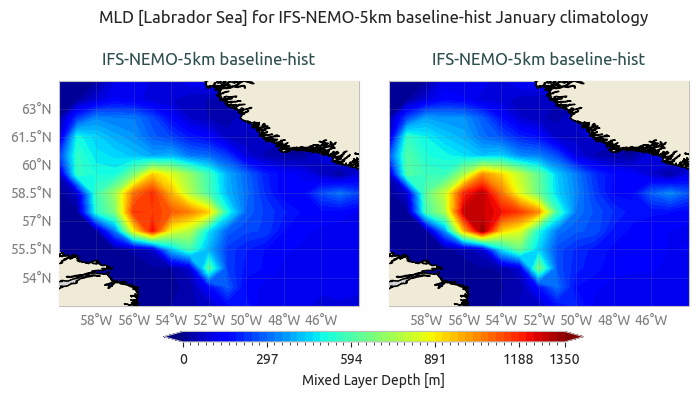

In [8]:
ps = PlotMLD(
    data=mld_init.data[["mld"]],
    obs=mld_init.data[["mld"]] * 1.1,
    loglevel="DEBUG",
)
ps.plot_mld()